In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from python.animation import *
from python.postprocess import *
from eval import *
sleap.versions()
sleap.system_summary()

from tqdm import tqdm

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


## Single animal model

In [7]:
def assign_id_to_points(all_tracked_points, frame_idx, polygon_constructor=poly_4):
    curr_frame_pts = all_tracked_points[frame_idx].copy()
    pt_cnt = len(curr_frame_pts)
    non_missing_mask = np.isnan(curr_frame_pts).sum(axis=1) == 0 # 1 = non-missing, 0 = missing
    
    # for missing points, interpolate from its two neighbors using polar coordinates
    polar_interpolated_pts = polar_interpolate(all_tracked_points[frame_idx], non_missing_mask)
    for pt_idx in range(pt_cnt):
        if non_missing_mask[pt_idx]:
            continue
        all_tracked_points[frame_idx][pt_idx] = polar_interpolated_pts[pt_idx]
    
    # assign order again to ensure maximal global alignment
    assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor)
        
def assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor=poly_4):
    curr_frame_pts = all_tracked_points[frame_idx]
    polygon_order = polygon_constructor(curr_frame_pts)
    best_shift = find_best_roll(curr_frame_pts[polygon_order], all_tracked_points[frame_idx-1])
    shifted_indices = np.roll(polygon_order, best_shift, axis=0)
    all_tracked_points[frame_idx] = curr_frame_pts[shifted_indices]

def polygon_correction_with_points(all_tracked_points, polygon_constructor=poly_4, return_indices=False):

    frame_cnt = all_tracked_points.shape[0]
    corrected_coords = all_tracked_points.copy()

    for frame_idx in tqdm(range(1, frame_cnt)):
        assign_id_to_points(corrected_coords, frame_idx, polygon_constructor)

    return corrected_coords



In [ ]:
single_model_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/predictions/animal_1_labels.v003.slp.250216_015520.predictions.slp'
single_model_dataset = sleap.load_file(single_model_dataset_path)
print(single_model_dataset)

In [8]:
single_model_tracked_points = get_all_tracked_points_single_model(single_model_dataset)
np.save('/home/mingxiao/Desktop/jellyfish/label/predictions/single_model_all_tracked_points.npy', single_model_tracked_points)

all_tracked_points shape: (3240000, 17, 2)


In [5]:
single_model_tracked_points = np.load('/home/mingxiao/Desktop/jellyfish/label/predictions/single_model_all_tracked_points.npy')

In [3]:
tracked_points_path = '/home/mingxiao/Desktop/jellyfish/label/predictions/single_model_all_tracked_points.npy'
eval_dataset_single_model(single_model_dataset_path, derivative_thres=10, tracked_points_path=tracked_points_path, use_mean=False)

NameError: name 'single_model_dataset_path' is not defined

total_range_length: 76184


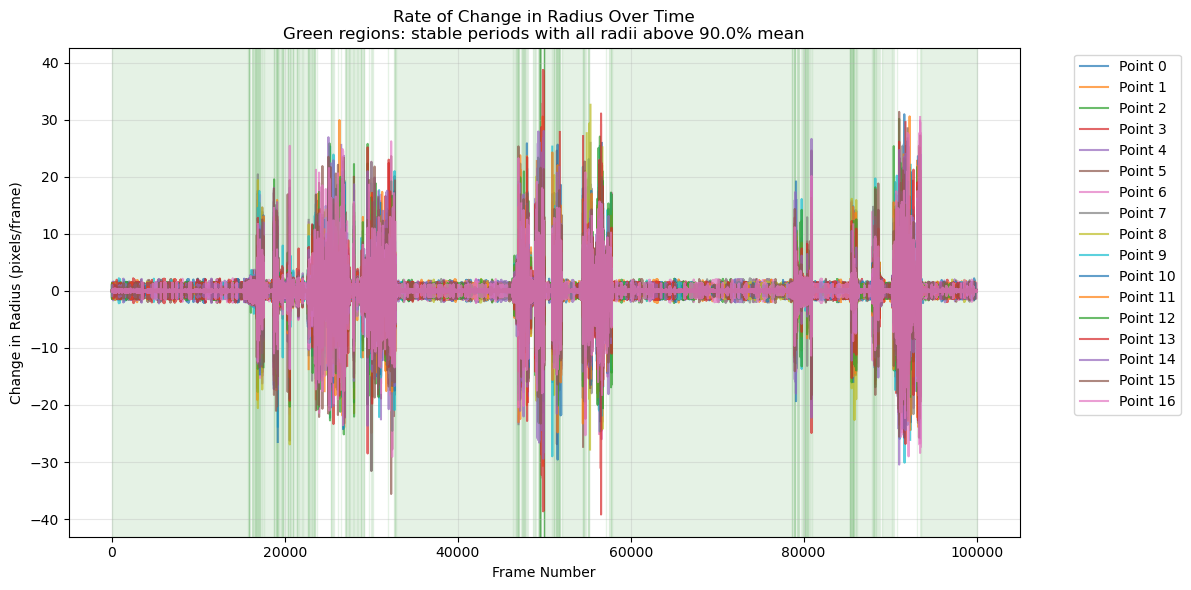

100%|██████████| 100000/100000 [01:16<00:00, 1302.15it/s]


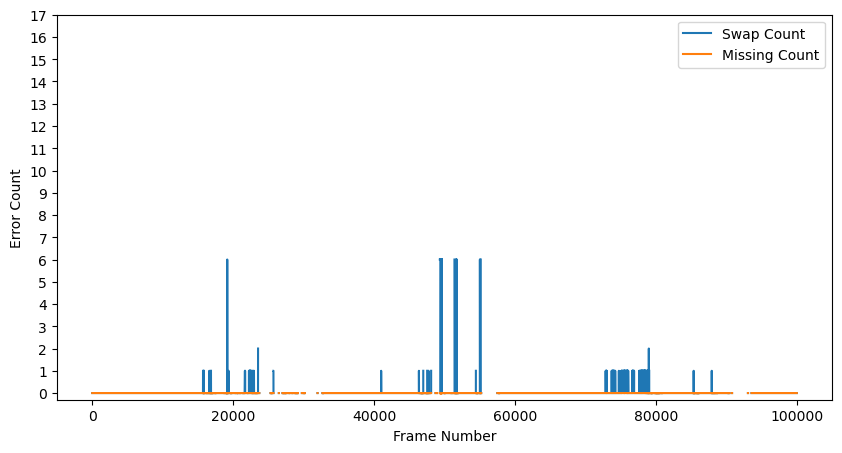

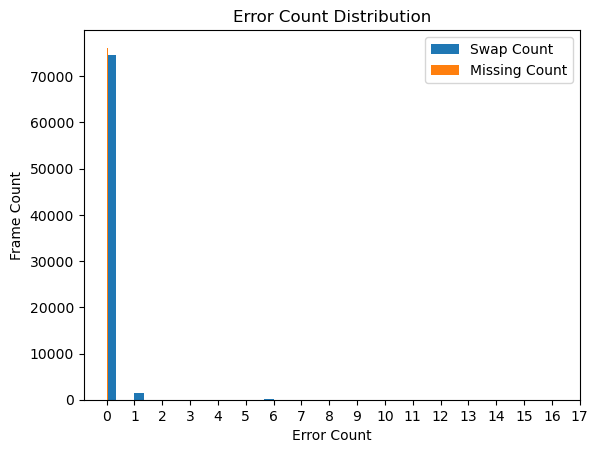

([0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,


In [6]:
eval_dataset_from_points(single_model_tracked_points[:100000], derivative_thres=5, use_mean=True, verbose=False, mean_scale=0.9)

In [8]:
single_model_tracked_points_corrected = polygon_correction_with_points(single_model_tracked_points[:100000])

100%|██████████| 99999/99999 [11:38<00:00, 143.18it/s]


total_range_length: 82804


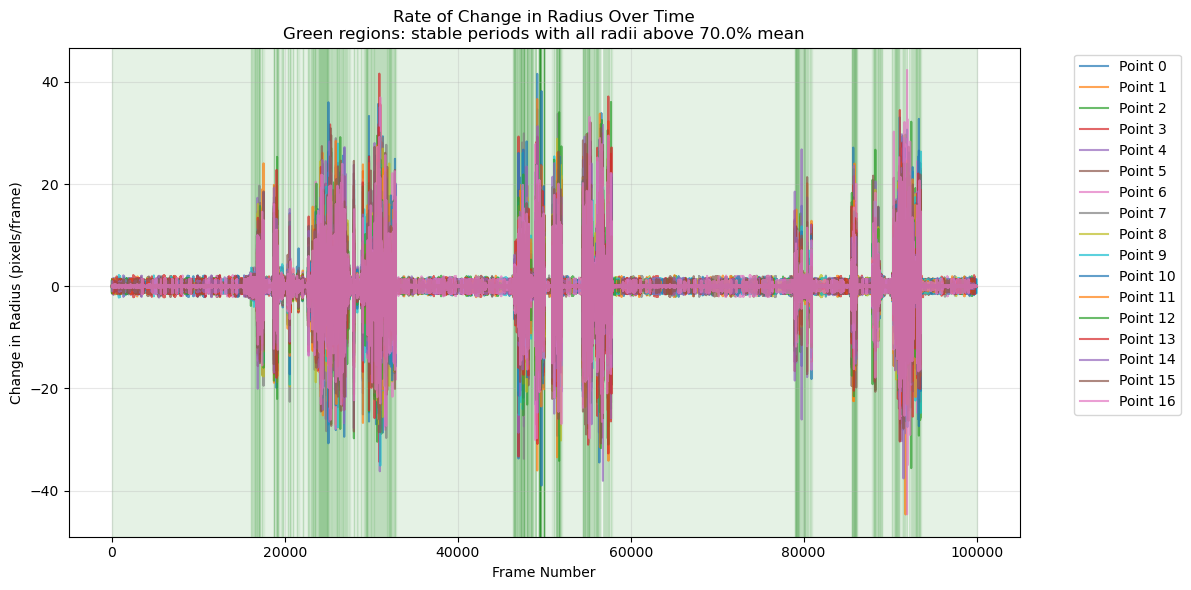

100%|██████████| 100000/100000 [01:23<00:00, 1192.91it/s]


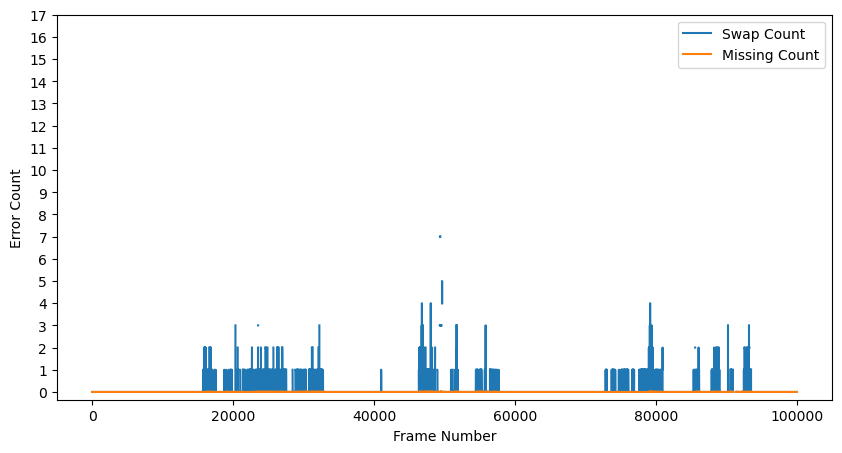

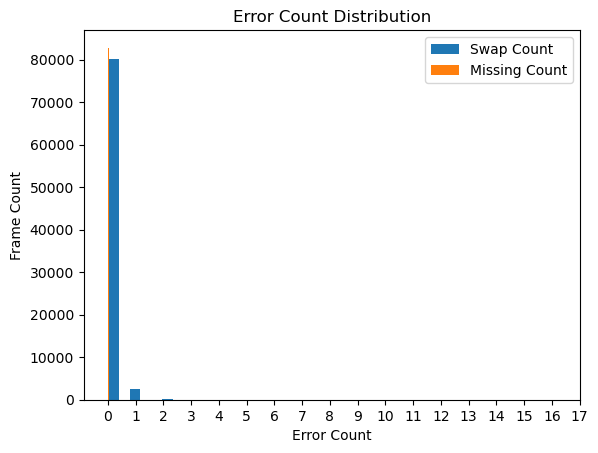

In [11]:
eval_dataset_from_points(single_model_tracked_points_corrected, derivative_thres=5, use_mean=True, verbose=False, mean_scale=0.7);

total_range_length: 79174


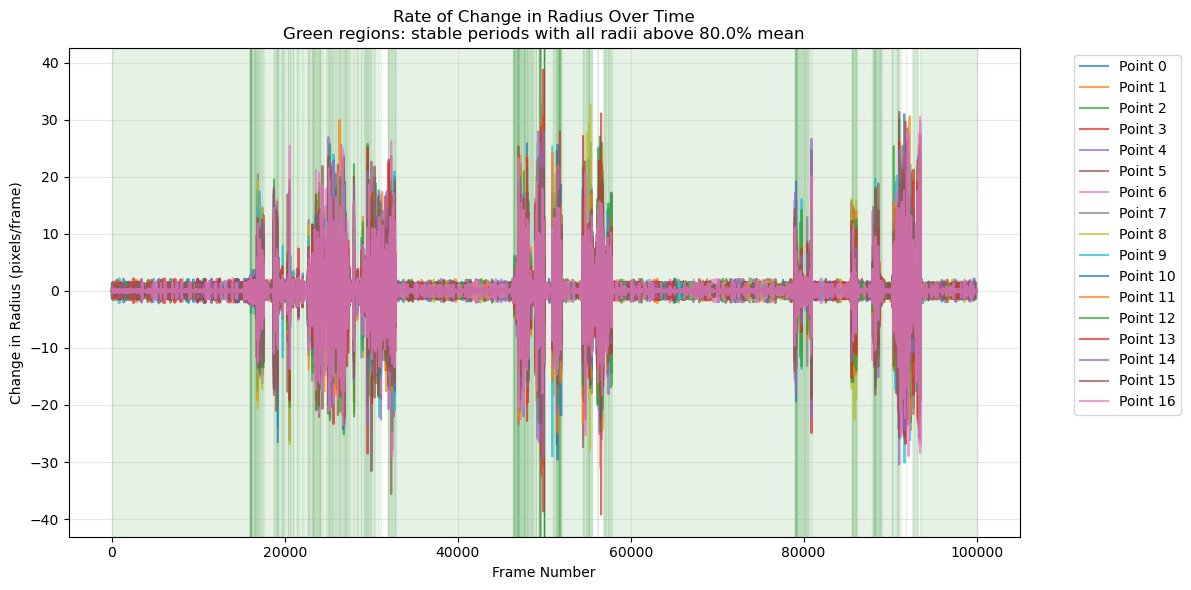

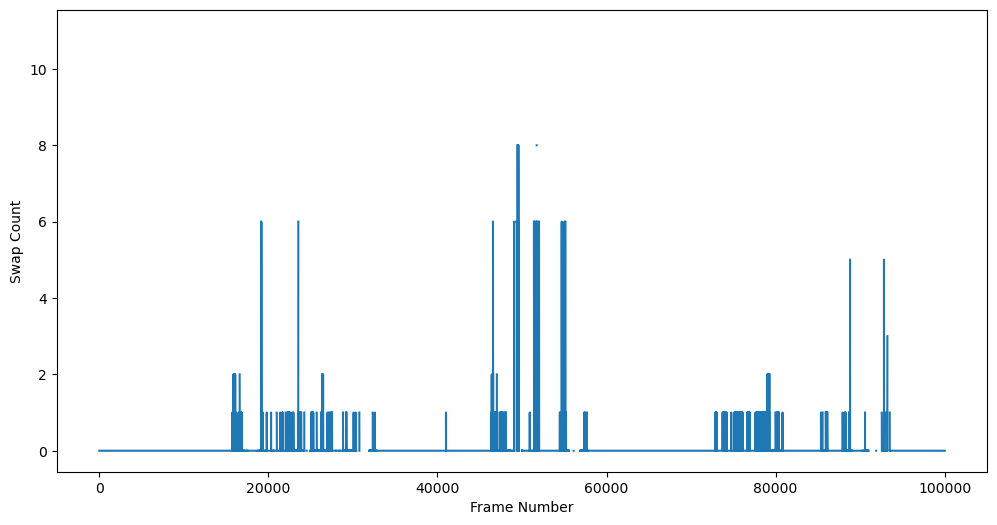

In [8]:
eval_dataset_from_points(single_model_tracked_points[:100000], derivative_thres=5, use_mean=True, verbose=False, mean_scale=0.8)

total_range_length: 37452


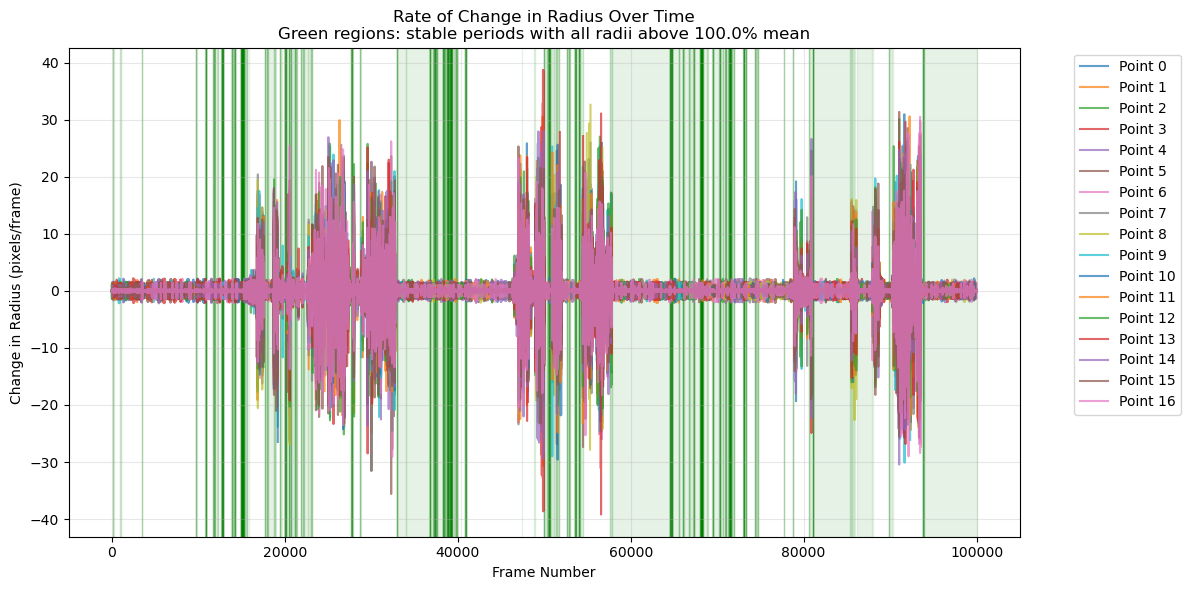

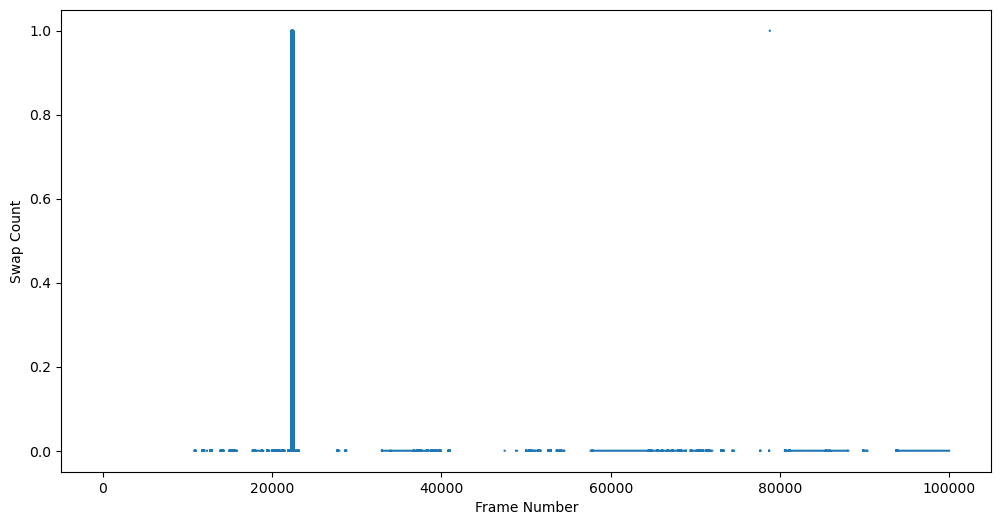

In [10]:
eval_dataset_from_points(single_model_tracked_points[:100000], derivative_thres=5, use_mean=True, verbose=False, mean_scale=1.0)

total_range_length: 1927332


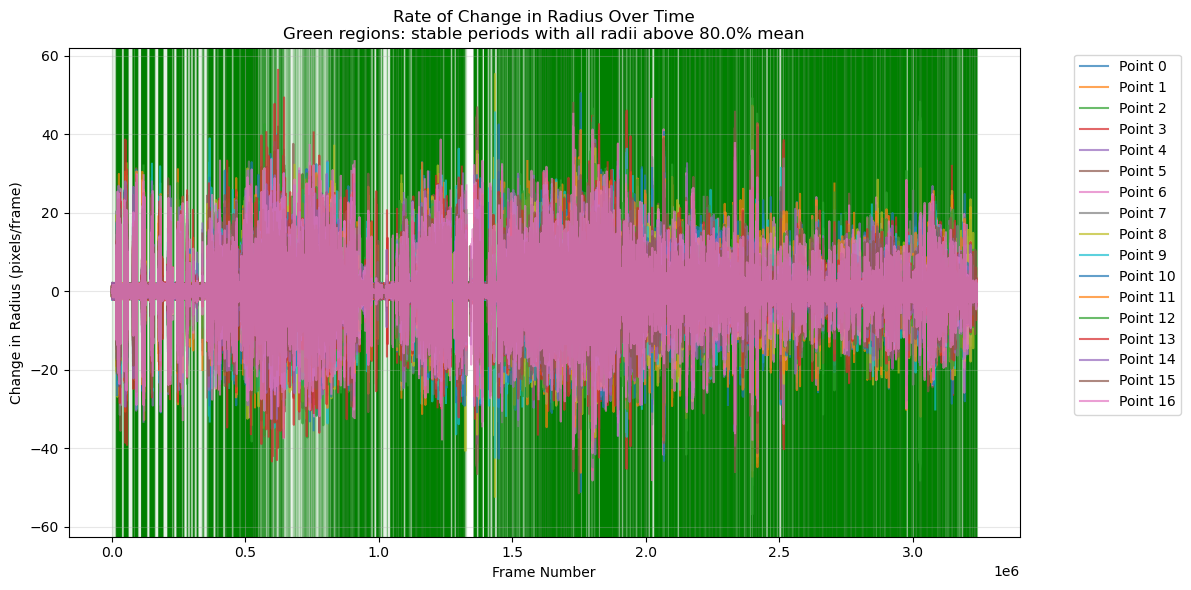

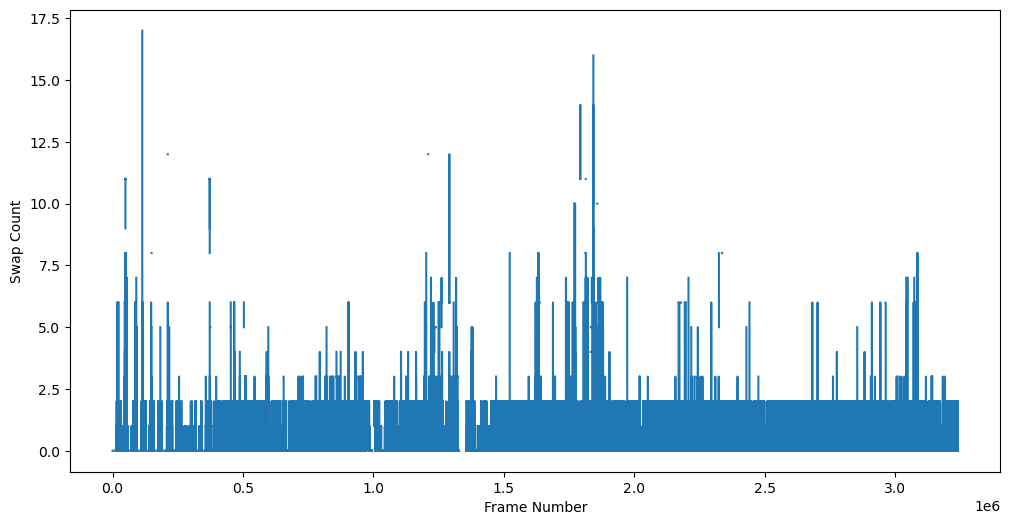

In [12]:
eval_dataset_from_points(single_model_tracked_points, derivative_thres=5, use_mean=True, verbose=False, mean_scale=0.8)

## Multi-animal top-down

### 5 min

Labels(labeled_frames=45000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (45000, 17, 2)
First non missing frame idx: 0
Missing point count: 72608
reorder_idx.shape: (17,)
total_range_length: 8776


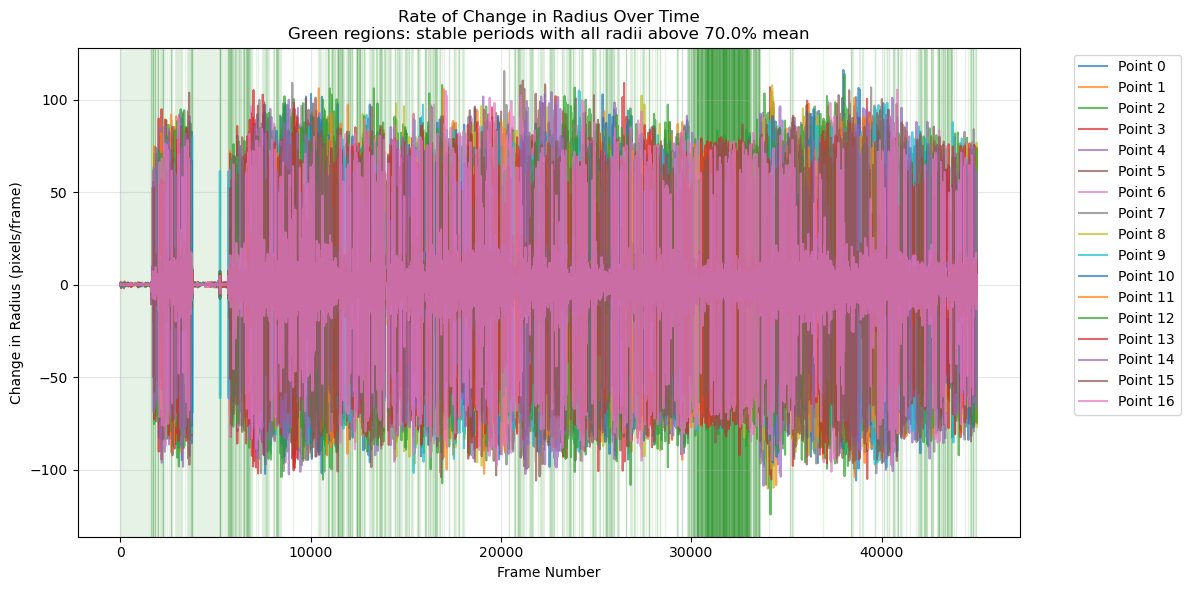

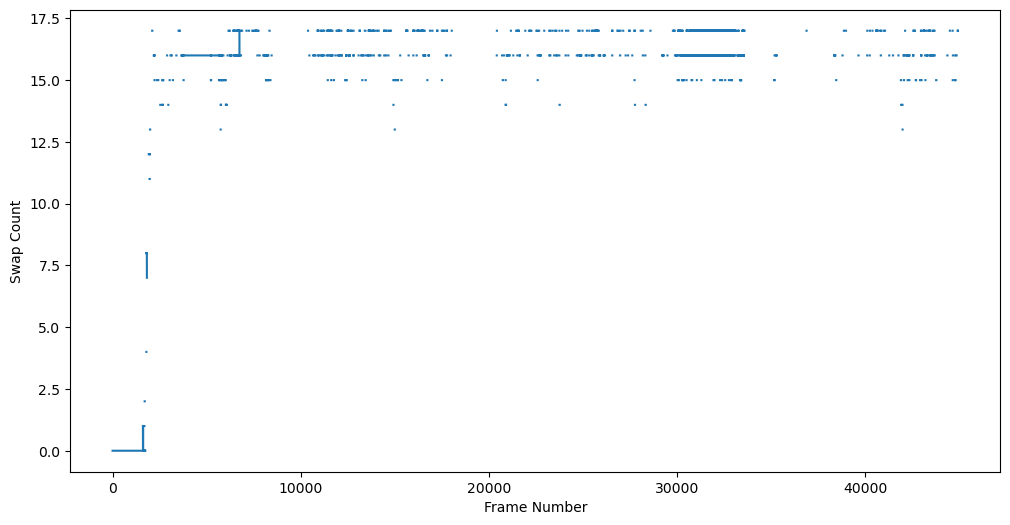

In [3]:
dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/reencoded_5min_v2.slp'
eval_dataset(dataset_path)

### 1 min

Getting all tracked points from Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)
total_range_length: 4264


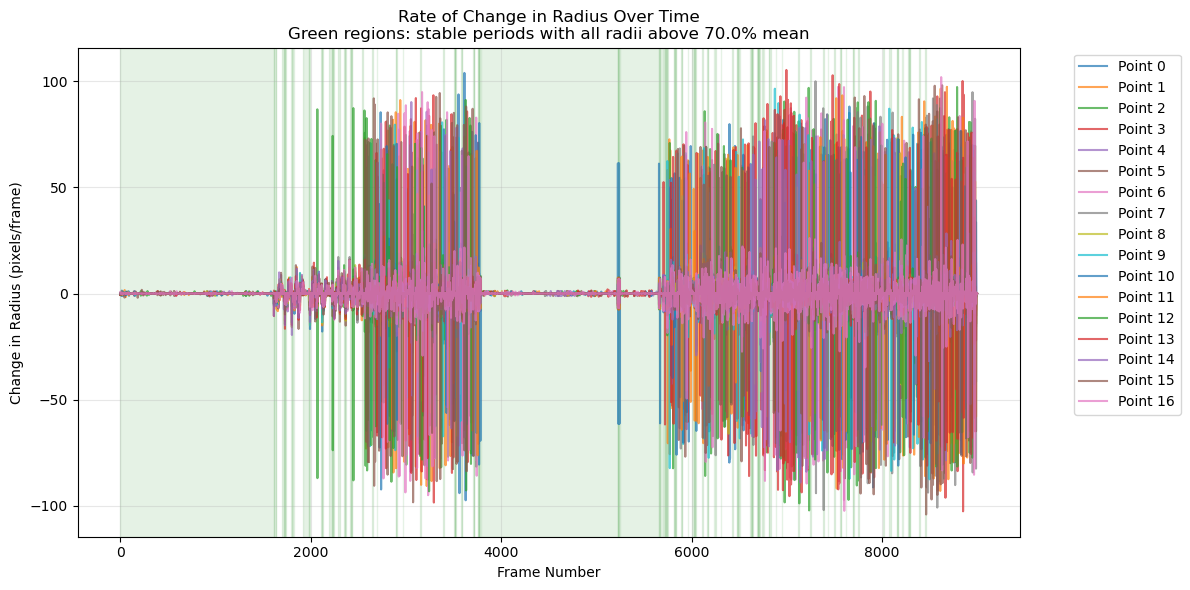

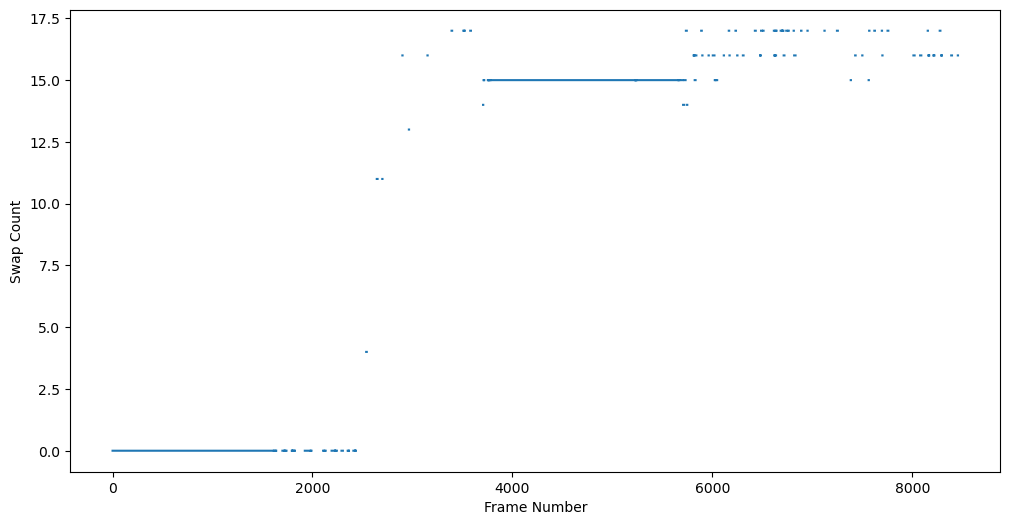

In [3]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
swap_cnt_lst_masked, filtered_ranges = eval_dataset(corrected_dataset_path, method='polygon', use_cached_pts=False)

total_range_length: 4264


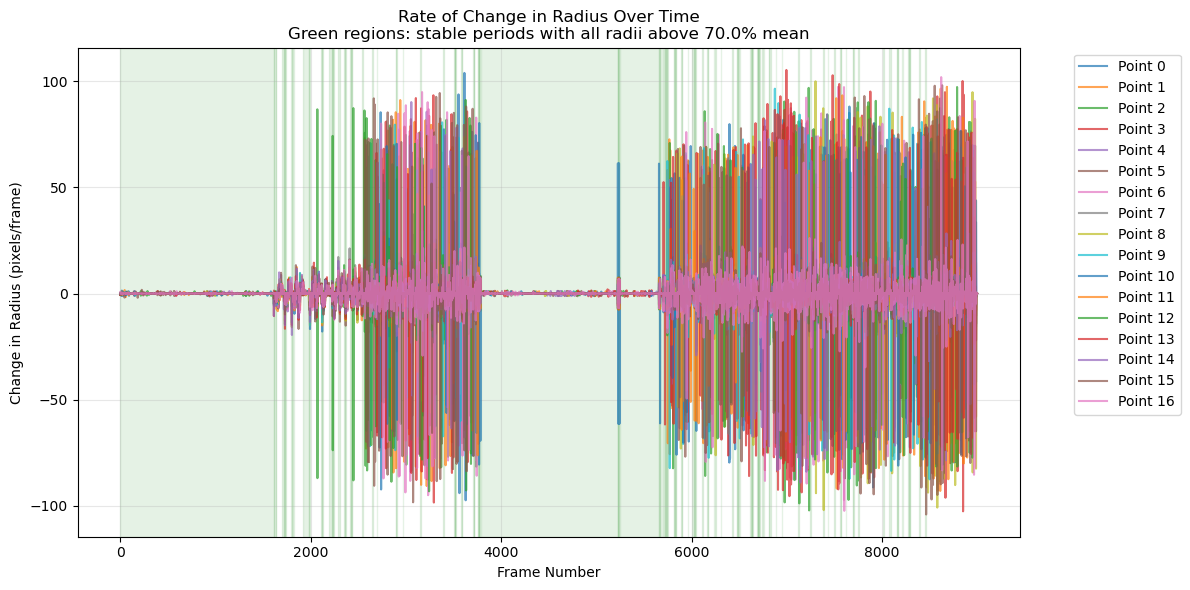

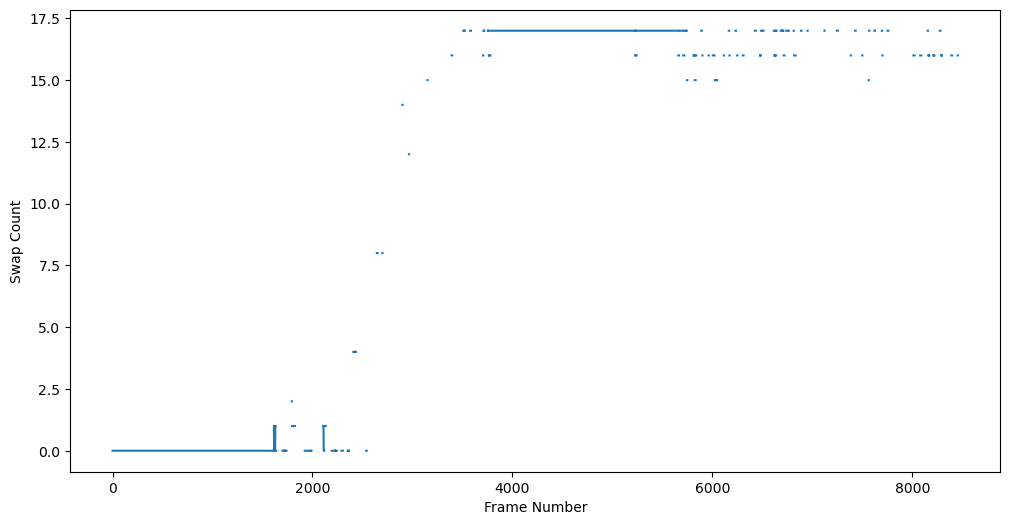

In [35]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
swap_cnt_lst_masked_2, filtered_ranges_2 = eval_dataset(corrected_dataset_path, method='nn')

#### examine swaps across frames

In [29]:
prev_swap_cnt = None
pre_start_idx = None
for i, cnt in enumerate(swap_cnt_lst_masked, start=1):
    if np.isnan(cnt) or cnt == 0:
        continue
    if prev_swap_cnt is None:
        prev_swap_cnt = cnt
        pre_start_idx = i
    elif cnt != prev_swap_cnt:
        print(f'Frame {pre_start_idx} to {i-1} has {int(prev_swap_cnt)} swaps')
        prev_swap_cnt = cnt
        pre_start_idx = i

Frame 2410 to 2643 has 4 swaps
Frame 2644 to 2894 has 8 swaps
Frame 2895 to 2899 has 10 swaps
Frame 2900 to 2964 has 14 swaps
Frame 2965 to 3150 has 12 swaps
Frame 3151 to 3391 has 15 swaps
Frame 3392 to 3509 has 16 swaps
Frame 3510 to 3588 has 17 swaps
Frame 3589 to 3711 has 16 swaps
Frame 3712 to 3764 has 17 swaps
Frame 3765 to 3783 has 16 swaps
Frame 3784 to 5227 has 17 swaps
Frame 5228 to 5232 has 16 swaps
Frame 5233 to 5239 has 17 swaps
Frame 5240 to 5244 has 16 swaps
Frame 5245 to 5659 has 17 swaps
Frame 5660 to 5670 has 16 swaps
Frame 5671 to 5707 has 17 swaps
Frame 5708 to 5722 has 16 swaps
Frame 5723 to 5747 has 17 swaps
Frame 5748 to 5812 has 15 swaps
Frame 5813 to 5823 has 16 swaps
Frame 5824 to 5835 has 15 swaps
Frame 5836 to 5888 has 16 swaps
Frame 5889 to 5899 has 17 swaps
Frame 5900 to 6024 has 16 swaps
Frame 6025 to 6114 has 15 swaps
Frame 6115 to 6164 has 16 swaps
Frame 6165 to 6171 has 17 swaps
Frame 6172 to 6231 has 16 swaps
Frame 6232 to 6248 has 17 swaps
Frame 6249

In [5]:
# dataset = sleap.load_file(corrected_dataset_path)
# tracked_points = get_all_tracked_points(dataset, reorder=True, interpolate=False, min_score=0, start_idx=0)
tracked_points_path = corrected_dataset_path.replace('.slp', '_tracked_points.npy')
tracked_points = np.load(tracked_points_path)
print(tracked_points.shape)

(9000, 17, 2)


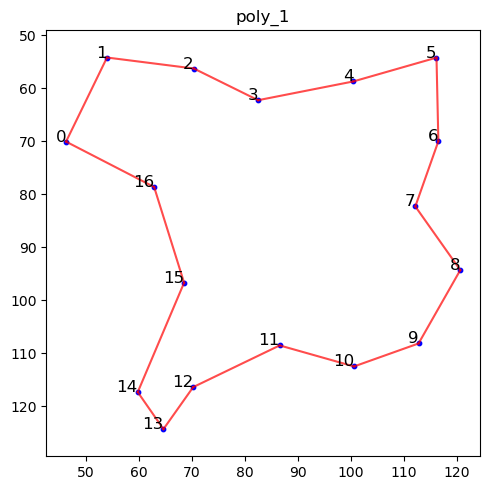


Total edge lengths:
poly_1: 265.625


In [33]:
plot_some_polygons(tracked_points[2408], [poly_3])

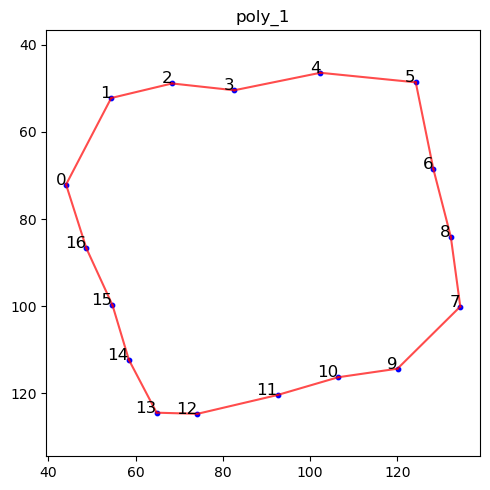


Total edge lengths:
poly_1: 278.844


In [34]:
plot_some_polygons(tracked_points[2409], [poly_3])

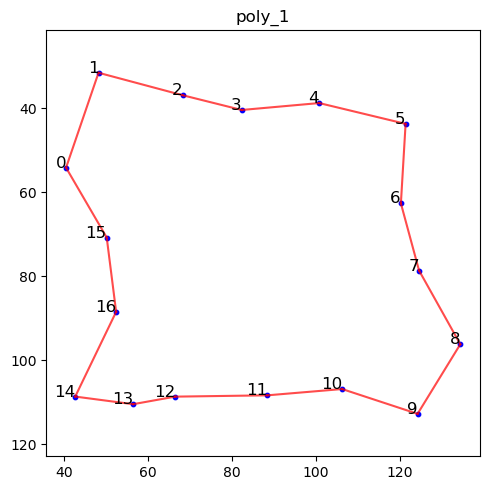


Total edge lengths:
poly_1: 316.303


In [25]:
plot_some_polygons(tracked_points[1922], [poly_3])

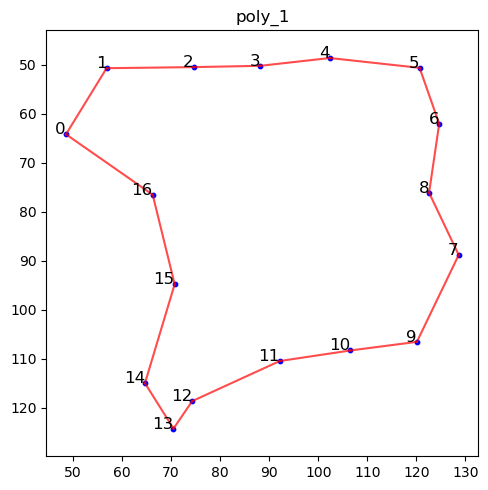


Total edge lengths:
poly_1: 266.962


In [13]:
selected_points = tracked_points[2522]
plot_some_polygons(selected_points, [poly_3])

In [25]:
def make_ccw(points, permutation=None, polygon_constructor=poly_3):
    if permutation is None:
        permutation = polygon_constructor(points)
    x = points[permutation, 0]
    y = points[permutation, 1]
    area = 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1]) + 0.5 * (x[-1] * y[0] - x[0] * y[-1])
    
    # If area is positive, the polygon is counterclockwise, so reverse the permutation
    if area < 0:
        permutation = permutation[::-1]
        print('reversed')
    
    return permutation

In [26]:
poly_4 = lambda points: make_ccw(points)

reversed


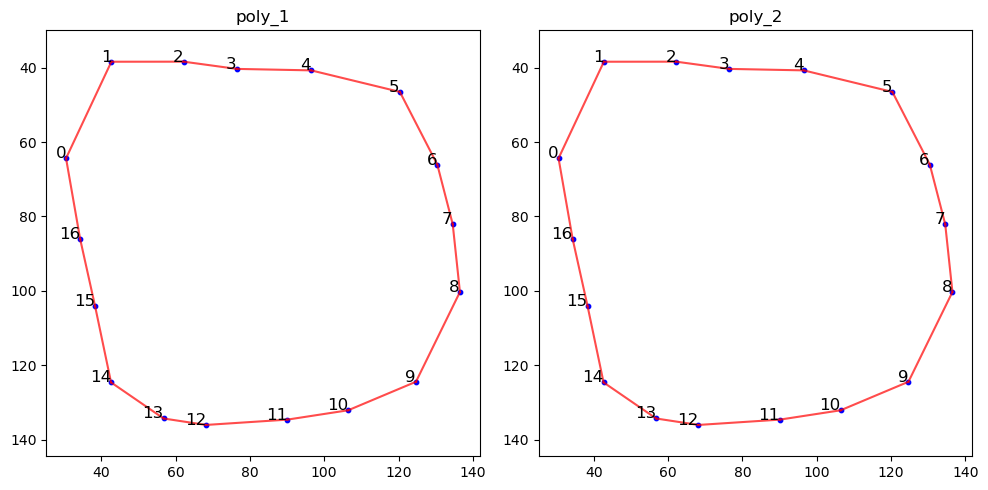


Total edge lengths:
poly_1: 339.387
poly_2: 339.387


In [27]:
selected_points = tracked_points[1522]
plot_some_polygons(selected_points, [poly_3, poly_4])

In [28]:
print(poly_3(selected_points))
print(poly_4(selected_points))

[0, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
reversed
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0]


#### examine intervals between expansion periods

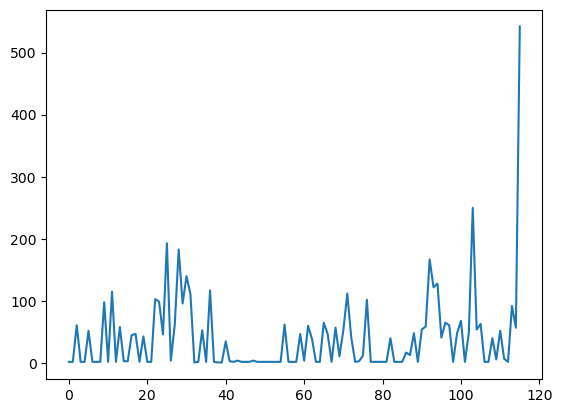

In [6]:
interval_btwn_expansions = []
for i, (start_idx, end_idx) in enumerate(filtered_ranges):
    if i == 0:
        if start_idx != 0:
            interval_btwn_expansions.append(start_idx)
    else:
        interval_btwn_expansions.append(start_idx - filtered_ranges[i-1][1])
total_frame_cnt = len(swap_cnt_lst_masked)
if total_frame_cnt > filtered_ranges[-1][1]:
    interval_btwn_expansions.append(total_frame_cnt - filtered_ranges[-1][1])
    
plt.plot(interval_btwn_expansions)
plt.show()


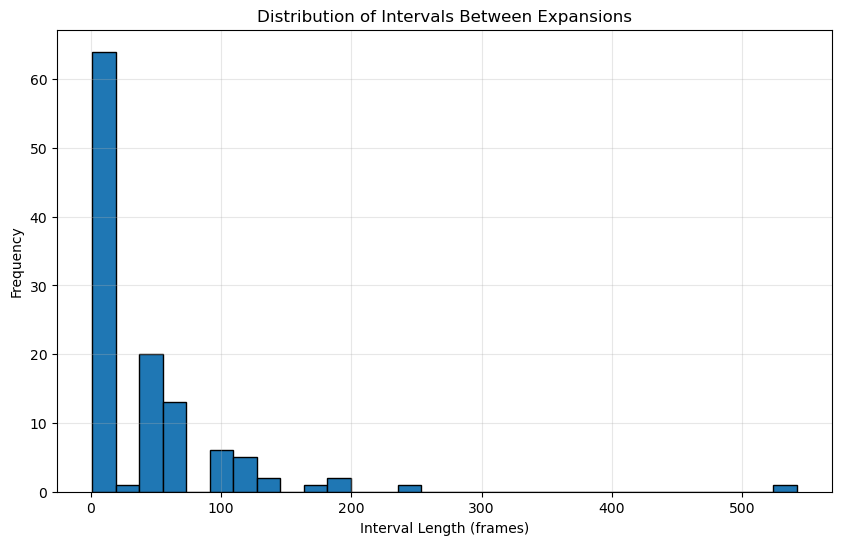

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(interval_btwn_expansions, bins=30, edgecolor='black')
plt.xlabel('Interval Length (frames)')
plt.ylabel('Frequency')
plt.title('Distribution of Intervals Between Expansions')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
dataset = sleap.load_file(dataset_path)
print(f'Getting all tracked points from \n{dataset}')
tracked_points = get_all_tracked_points(dataset, reorder=True, interpolate=False, min_score=0, start_idx=0)
frame_0_pts = tracked_points[0]

Getting all tracked points from 
Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)


In [6]:
poly_3(frame_0_pts)

[0, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

In [8]:
poly_3(tracked_points[2])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

total_range_length: 4258


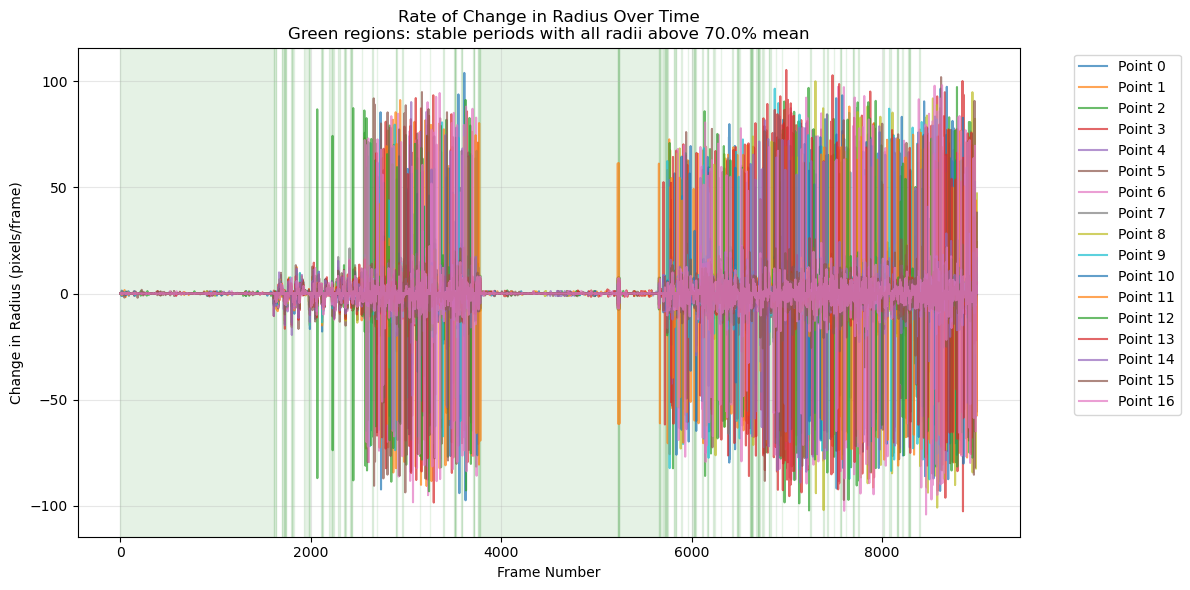

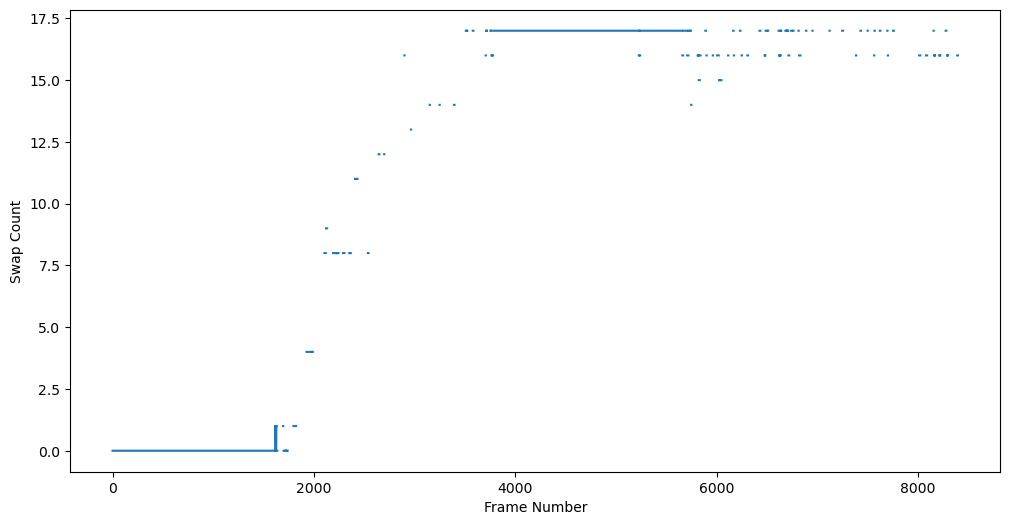

In [2]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
eval_dataset(corrected_dataset_path)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)
total_range_length: 4258


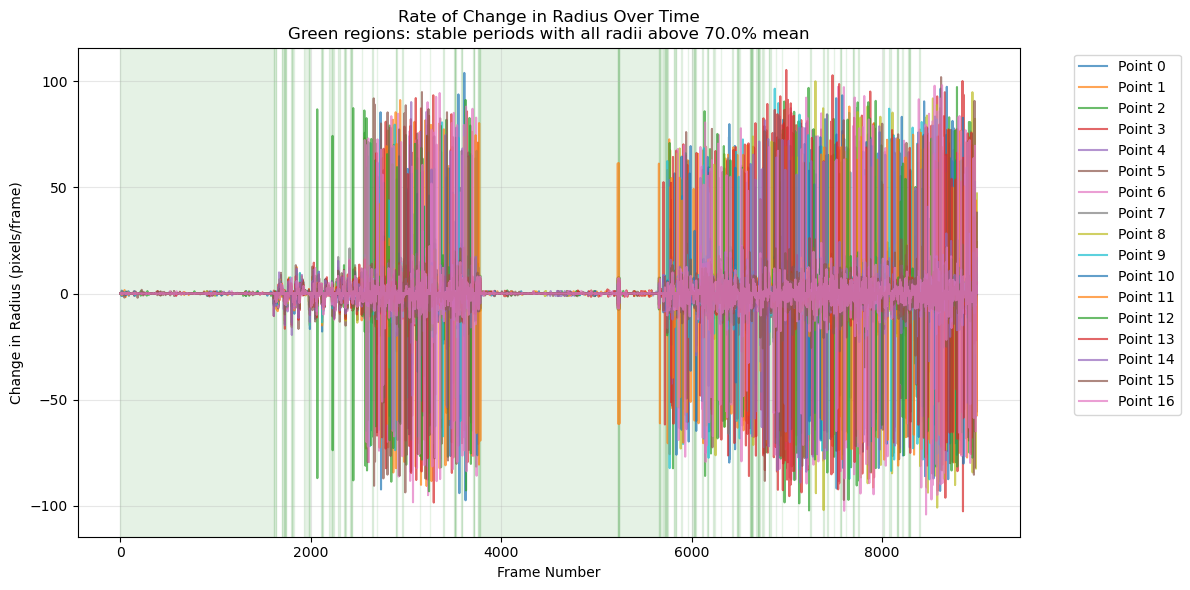

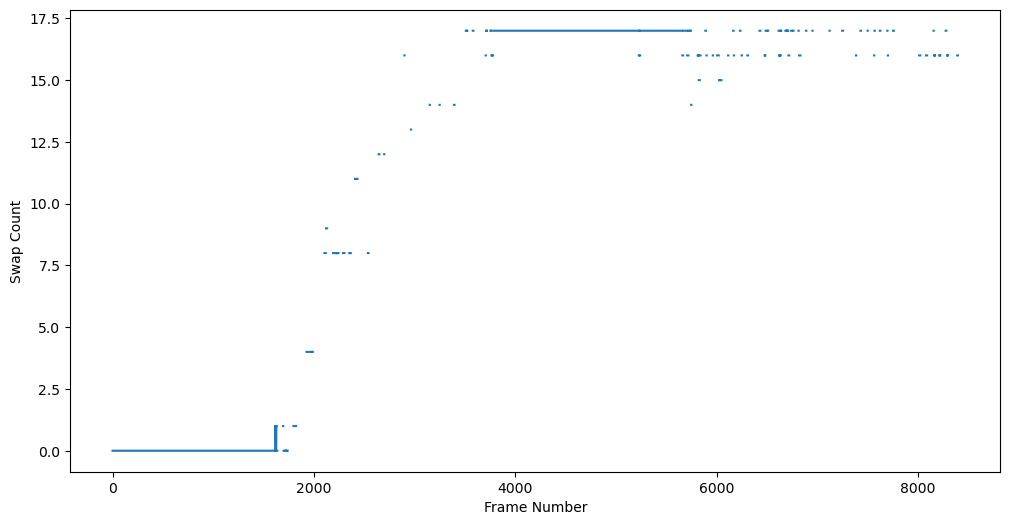

In [2]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
eval_dataset(corrected_dataset_path)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)
total_range_length: 4258


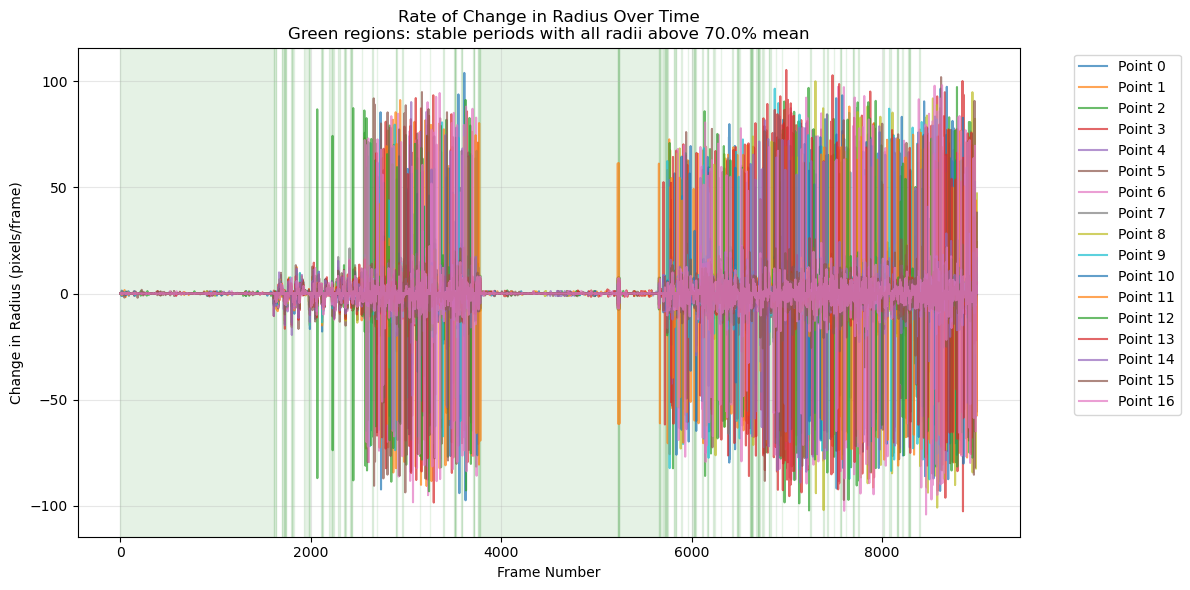

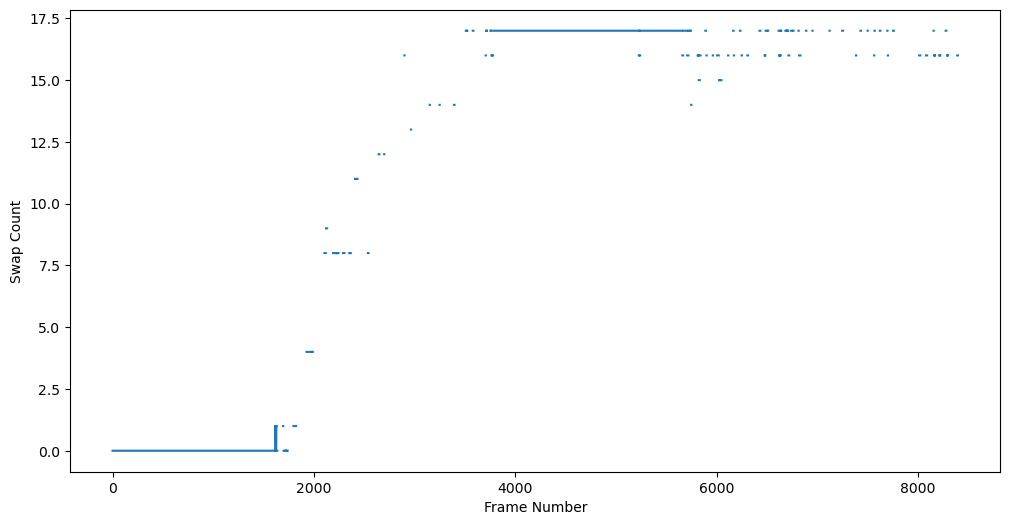

In [4]:
# new tracking results with window size 20
c0_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/v2_c0_training.slp'
eval_dataset(c0_dataset_path)

## Multi-animal top-down ID

Getting all tracked points from Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 18641
reorder_idx.shape: (17,)
total_range_length: 3501


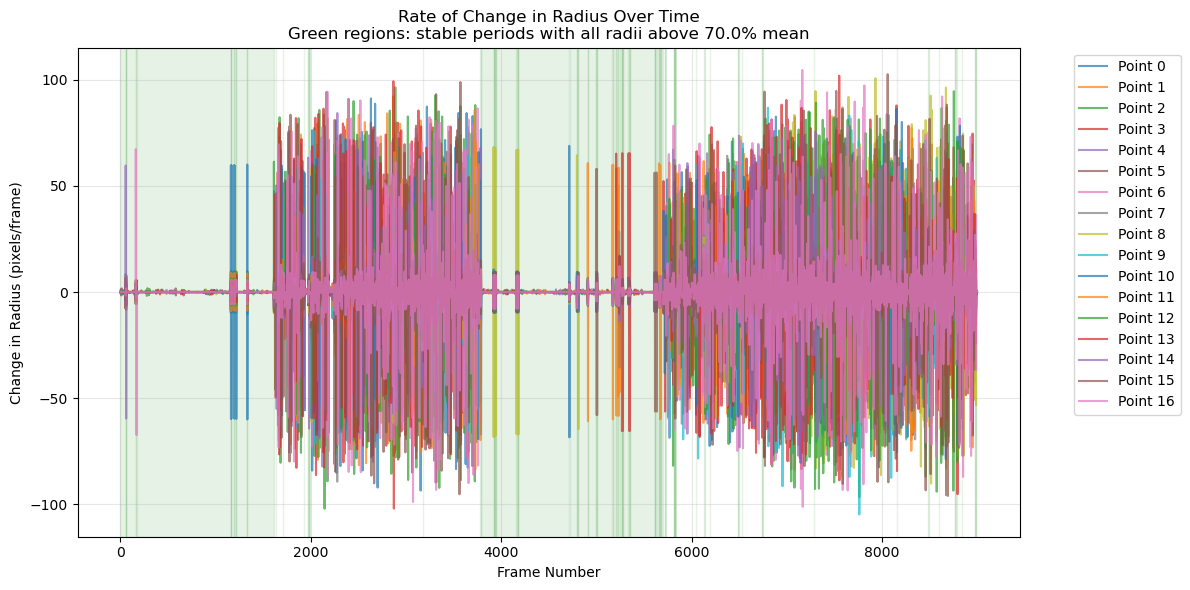

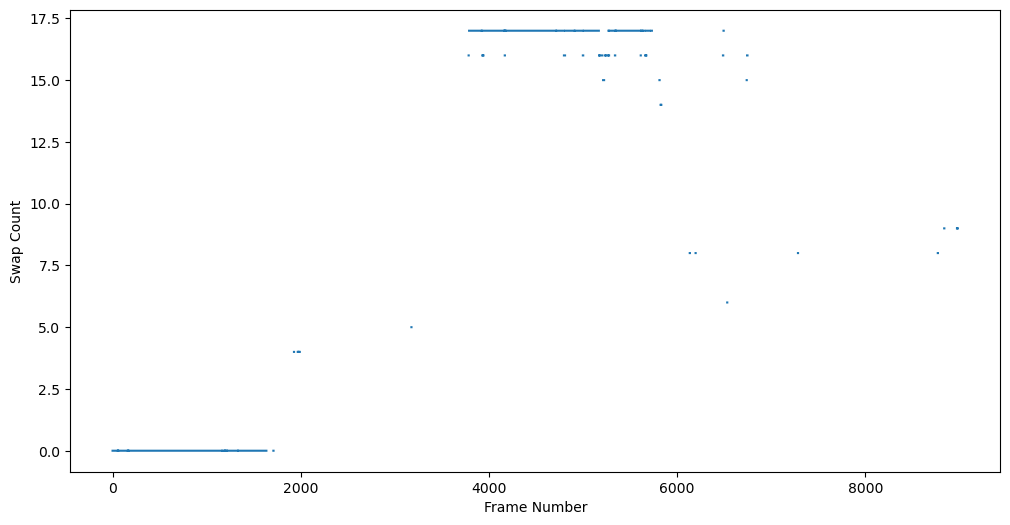

(array([ 0.,  0.,  0., ..., nan, nan, nan]),
 array([[   0,   55],
        [  57,   60],
        [  62,  161],
        [ 163,  169],
        [ 171, 1160],
        [1163, 1164],
        [1167, 1190],
        [1192, 1197],
        [1201, 1217],
        [1219, 1332],
        [1335, 1612],
        [1633, 1636],
        [1709, 1712],
        [1928, 1930],
        [1968, 1971],
        [1973, 1981],
        [1983, 1991],
        [3176, 3178],
        [3780, 3781],
        [3784, 3786],
        [3789, 3920],
        [3925, 3927],
        [3929, 3935],
        [3939, 3943],
        [3945, 4160],
        [4163, 4166],
        [4168, 4171],
        [4173, 4177],
        [4179, 4180],
        [4182, 4714],
        [4718, 4795],
        [4797, 4810],
        [4812, 4909],
        [4913, 4996],
        [4998, 5003],
        [5009, 5169],
        [5171, 5173],
        [5177, 5207],
        [5209, 5210],
        [5213, 5225],
        [5231, 5232],
        [5234, 5237],
        [5244, 5268],
        [

In [2]:
dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/v2_c0_training.slp.250214_215424.predictions.slp'
eval_dataset(dataset_path, method='polygon')

## Multi-animal top-down 4k

In [4]:
multi_4k_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10.slp.250221_051111.predictions.slp'
multi_4k_dataset = sleap.load_file(multi_4k_dataset_path)
print(multi_4k_dataset)

Labels(labeled_frames=3240000, videos=1, skeletons=1, tracks=0)


In [8]:
multi_4k_tracked_points = get_all_untracked_points(multi_4k_dataset, reorder=True, interpolate=False, min_score=0.5, start_idx=0)
multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_tracked_points.npy'
np.save(multi_4k_points_path, multi_4k_tracked_points)

all_untracked_points shape: (3240000, 18, 2)


100%|██████████| 3240000/3240000 [2:25:53<00:00, 370.15it/s]  


Missing point count: 0
reorder_idx.shape: (18,)
